<a href="https://colab.research.google.com/github/dr-koehler-ai/Sepsis-Clinical-Analytics-Project-V1/blob/main/Sepsis_Prediction_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Sepsis Survival Prediction V2**

*Objective*

*   Can clinical characteristics associated with sepsis status be used to build a simple baseline model prdeicting the sepsis label of a patient?

*Dataset*
*   40336 patients with a total of 1552210 datapoints, aggegrated with one datapoint per patient
*   38 clinical features
*   binary outcome (target variable: sepsis label)


*Workflow*
*   Data cleaning (V1)
*   EDA (V1)
*   Statistical Analysis (V1)
*   Logistic Regression (V1)
*   Machine Learning
**Text fett markieren**
*Clinical question*

*   Can clinical variables that differ between ICU patients who develop sepsis and those who do not be used to predict the sepsis label?

In [1]:
# Clinical Sepsis Analytics Dashboard (V2)
# =========================================

#Standard library

#Data manipulation
import kagglehub
from pathlib import Path
import pandas as pd
import numpy as np

#Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Statistics
from scipy import stats
from statistics import mean, stdev
from math import sqrt

# Data preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.utils import resample

# Data modeling
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay


# =========================
# 1. Dataset Download
# =========================

from google.colab import drive
drive.mount("/content/drive")

dataset_path = Path("/content/drive/MyDrive/AI_Healthcare/Sepsis_Prediction/sepsis_patient_level_dataset.csv")

data = pd.read_csv(dataset_path)

data.head()

Mounted at /content/drive


,Patient_ID,HR_mean,HR_max,MAP_mean,MAP_min,O2Sat_mean,O2Sat_min,Resp_mean,Resp_max,Lactate_mean,Lactate_max,Creatinine_mean,Creatinine_max,WBC_mean,WBC_max,Platelets_mean,Platelets_min,Age_first,Gender_first,SepsisPatient
0,1,101.571429,117.0,87.261905,44.00,91.477273,85.0,24.820000,32.0,NaN,NaN,0.700000,0.7,10.200000,14.7,327.500000,317.0,83.14,0,0
1,2,60.954545,94.0,66.704545,50.50,97.000000,94.0,14.236842,27.0,NaN,NaN,2.500000,2.5,11.000000,11.0,158.000000,158.0,75.91,0,0
2,3,79.611111,93.0,81.048000,62.67,95.431818,91.0,25.633333,40.0,NaN,NaN,0.866667,0.9,9.000000,10.0,479.666667,465.0,45.82,0,0
3,4,102.444444,113.0,67.147308,34.00,98.203704,95.5,18.884615,26.0,NaN,NaN,0.800000,0.8,7.600000,7.6,182.000000,144.0,65.71,0,0
4,5,73.916667,88.0,87.088235,73.00,97.500000,96.0,16.500000,21.0,NaN,NaN,0.633333,0.7,6.933333,8.1,279.000000,273.0,28.09,1,0


As there are only continious variables, a **Gaussian Naive Bayes model** was selected first.

              precision    recall  f1-score   support

           0       0.95      0.75      0.84      7482
           1       0.14      0.52      0.22       586

    accuracy                           0.74      8068
   macro avg       0.55      0.64      0.53      8068
weighted avg       0.89      0.74      0.80      8068



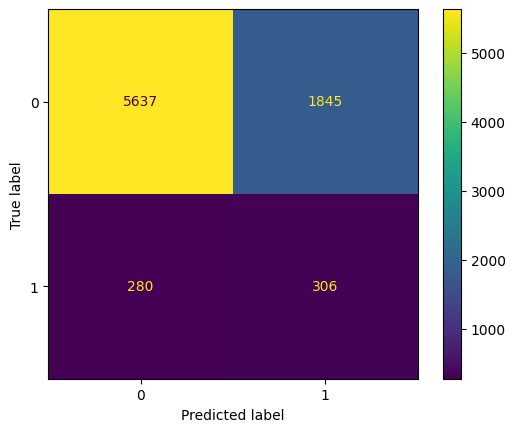

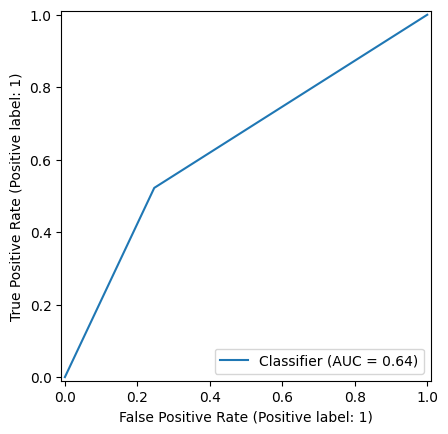

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.utils.class_weight import compute_sample_weight

primary_features = [
    "HR_mean",
    "MAP_min",
    "Resp_mean",
    "Creatinine_max",
    "Platelets_min",
    "Age_first"
]

y = data["SepsisPatient"]
X = data[primary_features]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Compute balanced weights for imbalanced y
sample_weight = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

# =========================
# Balanced GNB Pipeline
# =========================

#Pipeline with Median-inputer, scaler, GaussianNB
balanced_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("gnb", GaussianNB())
])

balanced_pipeline.fit(X_train, y_train, gnb__sample_weight=sample_weight)
y_pred = balanced_pipeline.predict(X_test)

#Classification Report
print(classification_report(y_test, y_pred))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=balanced_pipeline.classes_)
disp.plot()
plt.show()

#ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred)
plt.show()